In [ ]:
#dataset
!git clone https://github.com/pbharrin/machinelearninginaction3x.git

Cloning into 'machinelearninginaction3x'...
remote: Enumerating objects: 258, done.
remote: Total 258 (delta 0), reused 0 (delta 0), pack-reused 258 (from 1)
Receiving objects: 100% (258/258), 15.70 MiB | 13.25 MiB/s, done.
Resolving deltas: 100% (74/74), done.


In [ ]:
#import libraries
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
#check folders
base_path = "/content/machinelearninginaction3x/Ch02"

print(os.listdir(base_path))

['datingTestSet2.txt', 'digits.zip', 'datingTestSet.txt', 'EXTRAS', 'README.txt', 'kNNTest.py', 'kNN.py']


In [ ]:
import zipfile

zip_filepath = os.path.join(base_path, "digits.zip")

with zipfile.ZipFile(zip_filepath, 'r') as zip_ref:
    zip_ref.extractall(base_path)

print(os.listdir(base_path))

['datingTestSet2.txt', 'digits.zip', 'datingTestSet.txt', 'testDigits', 'EXTRAS', 'README.txt', 'trainingDigits', 'kNNTest.py', 'kNN.py']


In [ ]:
def img_to_vector(filename):
    vector = np.zeros((1, 1024))

    with open(filename, 'r') as f:
        for i in range(32):
            line = f.readline()

            for j in range(32):
                vector[0, 32*i + j] = int(line[j])

    return vector

In [ ]:
#load training data
training_path = os.path.join(base_path, "trainingDigits")

training_files = os.listdir(training_path)

X_train = []
y_train = []

for filename in training_files:

    # Example filename: 3_45.txt
    label = int(filename.split("_")[0])

    filepath = os.path.join(training_path, filename)

    vector = img_to_vector(filepath)

    X_train.append(vector[0])
    y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

print("Training samples:", X_train.shape)
print("Labels:", y_train.shape)

Training samples: (1934, 1024)
Labels: (1934,)


In [ ]:
#load test data
test_path = os.path.join(base_path, "testDigits")

test_files = os.listdir(test_path)

X_test = []
y_test = []

for filename in test_files:

    label = int(filename.split("_")[0])

    filepath = os.path.join(test_path, filename)

    vector = img_to_vector(filepath)

    X_test.append(vector[0])
    y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test samples:", X_test.shape)

Test samples: (946, 1024)


In [ ]:
#create KNN model and train it
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
#make predictions
y_pred = knn.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[4 4 5 1 1 7 0 4 6 3 8 7 1 2 3 7 5 4 4 0]


In [ ]:
#check accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9894291754756871
Accuracy (%): 98.94291754756871


In [ ]:
#test one handwritten
index = 10

sample = X_test[index].reshape(1, -1)

prediction = knn.predict(sample)

print("Predicted digit:", prediction[0])
print("Actual digit:", y_test[index])

Predicted digit: 8
Actual digit: 8


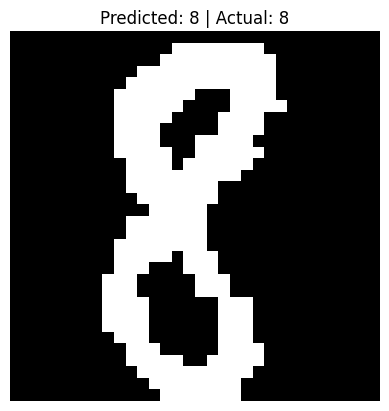

In [ ]:
#display
plt.imshow(X_test[index].reshape(32, 32), cmap='gray')
plt.title(f"Predicted: {prediction[0]} | Actual: {y_test[index]}")
plt.axis('off')
plt.show()

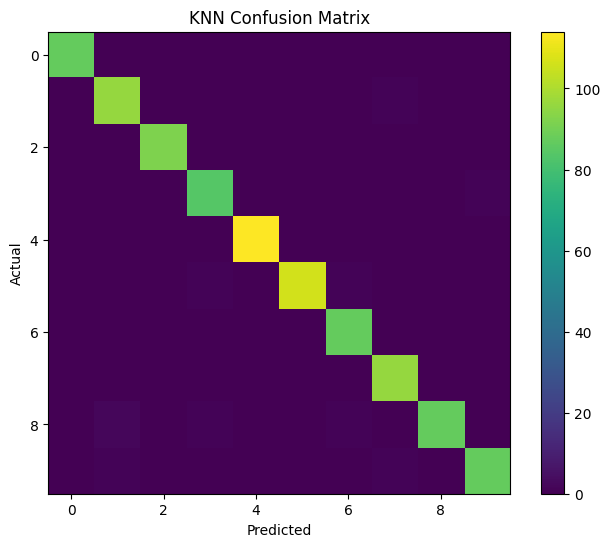

In [ ]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.colorbar()
plt.show()

In [ ]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       0.97      0.99      0.98        97
           2       1.00      1.00      1.00        92
           3       0.98      0.99      0.98        85
           4       1.00      1.00      1.00       114
           5       1.00      0.98      0.99       108
           6       0.98      1.00      0.99        87
           7       0.98      1.00      0.99        96
           8       1.00      0.96      0.98        91
           9       0.99      0.98      0.98        89

    accuracy                           0.99       946
   macro avg       0.99      0.99      0.99       946
weighted avg       0.99      0.99      0.99       946



In [ ]:
### Summary of this Notebook

#### What we did:
Built and evaluated a k-Nearest Neighbors (kNN) classifier to recognize handwritten digits (0-9) from $32 \times 32$ pixel text-based images.

#### How we did it:
1. **Data Download & Extraction:** Cloned the source repository and extracted the raw pixel text files from `digits.zip`.
2. **Preprocessing:** Converted each $32 \times 32$ image file into a $1 \times 1024$ flat binary vector (0s and 1s).
3. **Model Training:** Loaded 1,934 training samples, mapped their labels from filenames, and trained a Scikit-Learn `KNeighborsClassifier` with $k=3$.
4. **Evaluation:** Tested the model on 946 test samples, achieving **98.94% accuracy**. We visualized results using a sample prediction, a confusion matrix, and a classification report.